# Rx PD Model

Explores the Lending Default training and holdout data, then runs the **restaurant-level modeling pipeline** from `Restaurant_Default_Model.ipynb`: feature engineering, stratified train/test split, WoE binning, `ShapRFECV`, tuned logistic regression, and diagnostics (ROC/KS, deciles, VIF, correlation, SHAP).


In [1]:
# Optional: `toad` scorecard helpers
#
# If you have a diagnostic cell that does `site.addsitedir(...)` then `import toad`, you can
# **delete that cell**. On some macOS/Python setups the `toad` wheel installs metadata but
# `importlib.util.find_spec("toad")` stays `None`, so `import toad` still raises ModuleNotFoundError.
# This notebook pipeline does **not** require `toad`.
pass


In [2]:
import polars as pl
import numpy as np
import random

import seaborn as sns #For plotting graphs
sns.set_style("whitegrid")

import matplotlib.pyplot as plt #For plotting graphs
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

import seaborn as sns #For plotting graphs
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, \
accuracy_score, classification_report, confusion_matrix, mean_squared_error, \
balanced_accuracy_score,roc_curve,auc

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Recursive Feature Elimination
# from probatus.feature_elimination import ShapRFECV

# import shap
# shap.initjs()

# import toad  # optional dependency; disabled

# from optbinning import OptimalBinning


import os
from pathlib import Path

# Resolve data file location robustly regardless of execution cwd
CANDIDATE_DIRS = [
    Path.cwd(),
    Path.cwd() / 'data',
    Path('/Users/pradark/Documents/011. Work/Toast/Principal Data Scientist Capital Case Study'),
    Path('/Users/pradark/Documents/011. Work/Toast/Principal Data Scientist Capital Case Study/data'),
]


def _resolve_data_file(filename: str) -> str:
    for d in CANDIDATE_DIRS:
        fp = d / filename
        if fp.exists():
            return str(fp)
    raise FileNotFoundError(f'Could not locate {filename} in candidate dirs: {CANDIDATE_DIRS}')

import warnings
warnings.filterwarnings("ignore")

## Training Dataset

In [3]:
# Load training data
train_account = pl.read_csv(_resolve_data_file('Lending_default_train_account.csv'))
train_tx = pl.read_csv(_resolve_data_file('Lending_default_train_tx.csv'))
train_label = pl.read_csv(_resolve_data_file('Lending_default_train_label.csv'))

print('=' * 80)
print('TRAINING ACCOUNT DATA')
print('=' * 80)
print(f'Shape: {train_account.shape}')
print(f'\nColumns: {train_account.columns}')
print(f'\nData Types:\n{dict(zip(train_account.columns, train_account.dtypes))}')
print(f'\nMissing Values:\n{train_account.null_count()}')
print(f'\nFirst 5 rows:')
print(train_account.head())
print(f'\nBasic Statistics:')
print(train_account.describe())

TRAINING ACCOUNT DATA
Shape: (10812, 5)

Columns: ['', 'Restaurant_ID', 'Ownership_type', 'Restaurant_catagory', 'Market_segment']

Data Types:
{'': Int64, 'Restaurant_ID': String, 'Ownership_type': String, 'Restaurant_catagory': String, 'Market_segment': String}

Missing Values:
shape: (1, 5)
┌─────┬───────────────┬────────────────┬─────────────────────┬────────────────┐
│     ┆ Restaurant_ID ┆ Ownership_type ┆ Restaurant_catagory ┆ Market_segment │
│ --- ┆ ---           ┆ ---            ┆ ---                 ┆ ---            │
│ u32 ┆ u32           ┆ u32            ┆ u32                 ┆ u32            │
╞═════╪═══════════════╪════════════════╪═════════════════════╪════════════════╡
│ 0   ┆ 0             ┆ 220            ┆ 3                   ┆ 0              │
└─────┴───────────────┴────────────────┴─────────────────────┴────────────────┘

First 5 rows:
shape: (5, 5)
┌─────┬─────────────────────────────────┬────────────────┬─────────────────────┬────────────────┐
│     ┆ Restaurant

In [4]:
print('=' * 80)
print('TRAINING TRANSACTION DATA')
print('=' * 80)
print(f'Shape: {train_tx.shape}')
print(f'\nColumns: {train_tx.columns}')
print(f'\nData Types:\n{dict(zip(train_tx.columns, train_tx.dtypes))}')
print(f'\nMissing Values:\n{train_tx.null_count()}')
print(f'\nFirst 5 rows:')
print(train_tx.head())
print(f'\nBasic Statistics:')
print(train_tx.describe())

TRAINING TRANSACTION DATA
Shape: (3510679, 5)

Columns: ['', 'Restaurant_ID', 'Tx_date', 'processing_volume', 'Tx_hours']

Data Types:
{'': Int64, 'Restaurant_ID': String, 'Tx_date': String, 'processing_volume': Float64, 'Tx_hours': Float64}

Missing Values:
shape: (1, 5)
┌─────┬───────────────┬─────────┬───────────────────┬──────────┐
│     ┆ Restaurant_ID ┆ Tx_date ┆ processing_volume ┆ Tx_hours │
│ --- ┆ ---           ┆ ---     ┆ ---               ┆ ---      │
│ u32 ┆ u32           ┆ u32     ┆ u32               ┆ u32      │
╞═════╪═══════════════╪═════════╪═══════════════════╪══════════╡
│ 0   ┆ 0             ┆ 0       ┆ 0                 ┆ 0        │
└─────┴───────────────┴─────────┴───────────────────┴──────────┘

First 5 rows:
shape: (5, 5)
┌─────┬─────────────────────────────────┬────────────┬───────────────────┬──────────┐
│     ┆ Restaurant_ID                   ┆ Tx_date    ┆ processing_volume ┆ Tx_hours │
│ --- ┆ ---                             ┆ ---        ┆ ---             

In [5]:
print('=' * 80)
print('TRAINING LABEL DATA')
print('=' * 80)
print(f'Shape: {train_label.shape}')
print(f'\nColumns: {train_label.columns}')
print(f'\nData Types:\n{dict(zip(train_label.columns, train_label.dtypes))}')
print(f'\nMissing Values:\n{train_label.null_count()}')
print(f'\nFirst 5 rows:')
print(train_label.head())
print(f'\nLabel Distribution:')
label_col = train_label.columns[-1]
print(train_label.group_by(label_col).len().sort('len', descending=True))

TRAINING LABEL DATA
Shape: (10812, 3)

Columns: ['', 'Restaurant_ID', 'loan_default']

Data Types:
{'': Int64, 'Restaurant_ID': String, 'loan_default': Float64}

Missing Values:
shape: (1, 3)
┌─────┬───────────────┬──────────────┐
│     ┆ Restaurant_ID ┆ loan_default │
│ --- ┆ ---           ┆ ---          │
│ u32 ┆ u32           ┆ u32          │
╞═════╪═══════════════╪══════════════╡
│ 0   ┆ 0             ┆ 0            │
└─────┴───────────────┴──────────────┘

First 5 rows:
shape: (5, 3)
┌─────┬─────────────────────────────────┬──────────────┐
│     ┆ Restaurant_ID                   ┆ loan_default │
│ --- ┆ ---                             ┆ ---          │
│ i64 ┆ str                             ┆ f64          │
╞═════╪═════════════════════════════════╪══════════════╡
│ 0   ┆ cc3c8fb4-84c6-49c8-bcc7-6d23c6… ┆ 0.0          │
│ 1   ┆ 2c35efdf-410f-4188-bfe9-9777a7… ┆ 0.0          │
│ 2   ┆ 6fa519c2-e88c-4012-a981-4e4fa5… ┆ 1.0          │
│ 3   ┆ 541dd2c4-f612-4d28-9fae-7e28c9… ┆ 0.0     

## Holdout Dataset

In [6]:
# Load holdout data
holdout_account = pl.read_csv(_resolve_data_file('Lending_default_holdout_account.csv'))
holdout_tx = pl.read_csv(_resolve_data_file('Lending_default_holdout_tx.csv'))

print('=' * 80)
print('HOLDOUT ACCOUNT DATA')
print('=' * 80)
print(f'Shape: {holdout_account.shape}')
print(f'\nColumns: {holdout_account.columns}')
print(f'\nData Types:\n{dict(zip(holdout_account.columns, holdout_account.dtypes))}')
print(f'\nMissing Values:\n{holdout_account.null_count()}')
print(f'\nFirst 5 rows:')
print(holdout_account.head())
print(f'\nBasic Statistics:')
print(holdout_account.describe())

HOLDOUT ACCOUNT DATA
Shape: (4514, 5)

Columns: ['', 'Restaurant_ID', 'Ownership_type', 'Restaurant_catagory', 'Market_segment']

Data Types:
{'': Int64, 'Restaurant_ID': String, 'Ownership_type': String, 'Restaurant_catagory': String, 'Market_segment': String}

Missing Values:
shape: (1, 5)
┌─────┬───────────────┬────────────────┬─────────────────────┬────────────────┐
│     ┆ Restaurant_ID ┆ Ownership_type ┆ Restaurant_catagory ┆ Market_segment │
│ --- ┆ ---           ┆ ---            ┆ ---                 ┆ ---            │
│ u32 ┆ u32           ┆ u32            ┆ u32                 ┆ u32            │
╞═════╪═══════════════╪════════════════╪═════════════════════╪════════════════╡
│ 0   ┆ 0             ┆ 72             ┆ 3                   ┆ 0              │
└─────┴───────────────┴────────────────┴─────────────────────┴────────────────┘

First 5 rows:
shape: (5, 5)
┌─────┬───────────────────────────────┬─────────────────────┬─────────────────────┬────────────────┐
│     ┆ Restauran

In [7]:
print('=' * 80)
print('HOLDOUT TRANSACTION DATA')
print('=' * 80)
print(f'Shape: {holdout_tx.shape}')
print(f'\nColumns: {holdout_tx.columns}')
print(f'\nData Types:\n{dict(zip(holdout_tx.columns, holdout_tx.dtypes))}')
print(f'\nMissing Values:\n{holdout_tx.null_count()}')
print(f'\nFirst 5 rows:')
print(holdout_tx.head())
print(f'\nBasic Statistics:')
print(holdout_tx.describe())

HOLDOUT TRANSACTION DATA
Shape: (1471016, 5)

Columns: ['', 'Restaurant_ID', 'Tx_date', 'processing_volume', 'Tx_hours']

Data Types:
{'': Int64, 'Restaurant_ID': String, 'Tx_date': String, 'processing_volume': Float64, 'Tx_hours': Float64}

Missing Values:
shape: (1, 5)
┌─────┬───────────────┬─────────┬───────────────────┬──────────┐
│     ┆ Restaurant_ID ┆ Tx_date ┆ processing_volume ┆ Tx_hours │
│ --- ┆ ---           ┆ ---     ┆ ---               ┆ ---      │
│ u32 ┆ u32           ┆ u32     ┆ u32               ┆ u32      │
╞═════╪═══════════════╪═════════╪═══════════════════╪══════════╡
│ 0   ┆ 0             ┆ 0       ┆ 0                 ┆ 0        │
└─────┴───────────────┴─────────┴───────────────────┴──────────┘

First 5 rows:
shape: (5, 5)
┌─────┬─────────────────────────────────┬────────────┬───────────────────┬──────────┐
│     ┆ Restaurant_ID                   ┆ Tx_date    ┆ processing_volume ┆ Tx_hours │
│ --- ┆ ---                             ┆ ---        ┆ ---              

## Dataset Summary

In [8]:
print('=' * 80)
print('DATASET SUMMARY')
print('=' * 80)
print(f'\nTraining Set:')
print(f'  - Accounts: {len(train_account)}')
print(f'  - Transactions: {len(train_tx)}')
print(f'  - Labels: {len(train_label)}')

print(f'\nHoldout Set:')
print(f'  - Accounts: {len(holdout_account)}')
print(f'  - Transactions: {len(holdout_tx)}')

print(f'\nTotal:')
print(f'  - Total Accounts: {len(train_account) + len(holdout_account)}')
print(f'  - Total Transactions: {len(train_tx) + len(holdout_tx)}')

DATASET SUMMARY

Training Set:
  - Accounts: 10812
  - Transactions: 3510679
  - Labels: 10812

Holdout Set:
  - Accounts: 4514
  - Transactions: 1471016

Total:
  - Total Accounts: 15326
  - Total Transactions: 4981695


## Modeling pipeline (from `Restaurant_Default_Model.ipynb`)

**Restaurant-level aggregates**, **WoE** (`optbinning`), **RFE** (`probatus.ShapRFECV`),
**tuned logistic regression**, and **diagnostics** (ROC / KS, decile actual vs predicted, metrics, VIF, correlation, SHAP).

Install if needed: `optbinning`, `probatus`, `shap`, `statsmodels`, `scikit-learn`, `matplotlib`, `seaborn`.


In [9]:
# Build rolling time-series features by Restaurant_ID and snapshot Tx_date
LABEL_KEY = 'Restaurant_ID'

# Standardize dataframe names with df_ prefix
df_train_account = train_account.clone()
df_train_tx = train_tx.clone()
df_train_label = train_label.clone()
df_holdout_account = holdout_account.clone()
df_holdout_tx = holdout_tx.clone()

def _build_timeseries_features(df_tx, windows=(7, 30, 90, 180)):
    df_work = (
        df_tx
        .select([LABEL_KEY, 'Tx_date', 'processing_volume', 'Tx_hours'])
        .with_columns(pl.col('Tx_date').str.to_date(strict=False))
        .sort([LABEL_KEY, 'Tx_date'])
    )

    df_snapshots = df_work.select([LABEL_KEY, 'Tx_date']).unique().sort([LABEL_KEY, 'Tx_date'])

    for window in windows:
        df_window = (
            df_work
            .group_by_dynamic(
                index_column='Tx_date',
                group_by=LABEL_KEY,
                every='1d',
                period=f'{window}d',
                closed='right',
            )
            .agg([
                pl.col('processing_volume').mean().alias('avg_proc_vol'),
                pl.col('processing_volume').min().alias('min_proc_vol'),
                pl.col('processing_volume').max().alias('max_proc_vol'),
                pl.col('processing_volume').std().alias('std_proc_vol'),
                pl.col('Tx_hours').mean().alias('avg_tx_hours'),
                pl.col('Tx_hours').min().alias('min_tx_hours'),
                pl.col('Tx_hours').max().alias('max_tx_hours'),
                pl.col('Tx_hours').std().alias('std_tx_hours'),
            ])
            .with_columns([
                pl.when(pl.col('avg_proc_vol') != 0)
                .then(pl.col('std_proc_vol') / pl.col('avg_proc_vol'))
                .otherwise(None)
                .alias(f'cv_proc_vol_{window}d'),
                pl.when(pl.col('avg_tx_hours') != 0)
                .then(pl.col('std_tx_hours') / pl.col('avg_tx_hours'))
                .otherwise(None)
                .alias(f'cv_tx_hours_{window}d'),
            ])
            .rename({
                'avg_proc_vol': f'avg_proc_vol_{window}d',
                'min_proc_vol': f'min_proc_vol_{window}d',
                'max_proc_vol': f'max_proc_vol_{window}d',
                'avg_tx_hours': f'avg_tx_hours_{window}d',
                'min_tx_hours': f'min_tx_hours_{window}d',
                'max_tx_hours': f'max_tx_hours_{window}d',
            })
            .select([
                LABEL_KEY,
                'Tx_date',
                f'avg_proc_vol_{window}d',
                f'min_proc_vol_{window}d',
                f'max_proc_vol_{window}d',
                f'avg_tx_hours_{window}d',
                f'min_tx_hours_{window}d',
                f'max_tx_hours_{window}d',
                f'cv_proc_vol_{window}d',
                f'cv_tx_hours_{window}d',
            ])
        )

        df_snapshots = df_snapshots.join(df_window, on=[LABEL_KEY, 'Tx_date'], how='left')

    # Momentum features: percent change vs exact lag date (current vs N days ago).
    df_daily = (
        df_work
        .select([LABEL_KEY, 'Tx_date', 'processing_volume', 'Tx_hours'])
        .unique()
        .rename({
            'processing_volume': 'curr_processing_volume',
            'Tx_hours': 'curr_tx_hours',
        })
    )
    df_snapshots = df_snapshots.join(df_daily, on=[LABEL_KEY, 'Tx_date'], how='left')

    for lag_days in windows:
        lag_df = (
            df_daily
            .with_columns((pl.col('Tx_date') + pl.duration(days=lag_days)).alias('Tx_date'))
            .rename({
                'curr_processing_volume': f'proc_vol_{lag_days}d_ago',
                'curr_tx_hours': f'tx_hours_{lag_days}d_ago',
            })
        )

        df_snapshots = df_snapshots.join(lag_df, on=[LABEL_KEY, 'Tx_date'], how='left')

        df_snapshots = df_snapshots.with_columns([
            pl.when(pl.col(f'proc_vol_{lag_days}d_ago') != 0)
            .then(
                (pl.col('curr_processing_volume') - pl.col(f'proc_vol_{lag_days}d_ago'))
                / pl.col(f'proc_vol_{lag_days}d_ago')
            )
            .otherwise(None)
            .alias(f'pct_change_proc_vol_vs_{lag_days}d_ago'),
            pl.when(pl.col(f'tx_hours_{lag_days}d_ago') != 0)
            .then(
                (pl.col('curr_tx_hours') - pl.col(f'tx_hours_{lag_days}d_ago'))
                / pl.col(f'tx_hours_{lag_days}d_ago')
            )
            .otherwise(None)
            .alias(f'pct_change_tx_hours_vs_{lag_days}d_ago'),
        ])

    df_snapshots = df_snapshots.with_columns([
        pl.col('Tx_date').dt.weekday().alias('snapshot_day_of_week'),
        pl.col('Tx_date').dt.ordinal_day().alias('snapshot_day_of_year'),
        pl.col('Tx_date').dt.month().alias('snapshot_month'),
        pl.col('Tx_date').dt.quarter().alias('snapshot_quarter'),
    ])

    return df_snapshots.sort([LABEL_KEY, 'Tx_date'])


df_train_features = _build_timeseries_features(df_train_tx)
df_holdoutfeatures = _build_timeseries_features(df_holdout_tx)

# Remove source file index artifacts before merge (avoids Unnamed: 0_x / Unnamed: 0_y).
df_train_account_clean = df_train_account.select([c for c in df_train_account.columns if not c.startswith('Unnamed:')])
df_train_label_clean = df_train_label.select([c for c in df_train_label.columns if not c.startswith('Unnamed:')])
df_holdout_account_clean = df_holdout_account.select([c for c in df_holdout_account.columns if not c.startswith('Unnamed:')])

# Merge requested datasets
# train = account + features + labels
# holdout = account + features
df_train_merged = (
    df_train_features
    .join(df_train_account_clean, on=LABEL_KEY, how='left')
    .join(df_train_label_clean, on=LABEL_KEY, how='left')
)
df_holdout_merged = df_holdoutfeatures.join(df_holdout_account_clean, on=LABEL_KEY, how='left')

print('df_train_features shape:', df_train_features.shape)
print('df_holdoutfeatures shape:', df_holdoutfeatures.shape)
print('df_train_merged shape:', df_train_merged.shape)
print('df_holdout_merged shape:', df_holdout_merged.shape)
print('Any Unnamed columns (train)?', any(c.startswith('Unnamed:') for c in df_train_merged.columns))
print('Any Unnamed columns (holdout)?', any(c.startswith('Unnamed:') for c in df_holdout_merged.columns))

df_train_features shape: (3510679, 56)
df_holdoutfeatures shape: (1471016, 56)
df_train_merged shape: (3510679, 62)
df_holdout_merged shape: (1471016, 60)
Any Unnamed columns (train)? False
Any Unnamed columns (holdout)? False


In [10]:
df_holdout_merged.head()

Restaurant_ID,Tx_date,avg_proc_vol_7d,min_proc_vol_7d,max_proc_vol_7d,avg_tx_hours_7d,min_tx_hours_7d,max_tx_hours_7d,cv_proc_vol_7d,cv_tx_hours_7d,avg_proc_vol_30d,min_proc_vol_30d,max_proc_vol_30d,avg_tx_hours_30d,min_tx_hours_30d,max_tx_hours_30d,cv_proc_vol_30d,cv_tx_hours_30d,avg_proc_vol_90d,min_proc_vol_90d,max_proc_vol_90d,avg_tx_hours_90d,min_tx_hours_90d,max_tx_hours_90d,cv_proc_vol_90d,cv_tx_hours_90d,avg_proc_vol_180d,min_proc_vol_180d,max_proc_vol_180d,avg_tx_hours_180d,min_tx_hours_180d,max_tx_hours_180d,cv_proc_vol_180d,cv_tx_hours_180d,curr_processing_volume,curr_tx_hours,proc_vol_7d_ago,tx_hours_7d_ago,pct_change_proc_vol_vs_7d_ago,pct_change_tx_hours_vs_7d_ago,proc_vol_30d_ago,tx_hours_30d_ago,pct_change_proc_vol_vs_30d_ago,pct_change_tx_hours_vs_30d_ago,proc_vol_90d_ago,tx_hours_90d_ago,pct_change_proc_vol_vs_90d_ago,pct_change_tx_hours_vs_90d_ago,proc_vol_180d_ago,tx_hours_180d_ago,pct_change_proc_vol_vs_180d_ago,pct_change_tx_hours_vs_180d_ago,snapshot_day_of_week,snapshot_day_of_year,snapshot_month,snapshot_quarter,,Ownership_type,Restaurant_catagory,Market_segment
str,date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i16,i8,i8,i64,str,str,str
"""00122837-df5b-496a-9eab-58da8b…",2021-07-02,6256.377143,0.0,18947.42,5.142857,0.0,11.0,1.292321,1.025398,8865.293667,0.0,20325.8,7.5,0.0,13.0,0.800846,0.670563,6528.674667,0.0,20325.8,5.455556,0.0,13.0,1.080895,0.898048,7555.129778,0.0,32640.43,6.205556,0.0,17.0,0.957875,0.748647,11621.65,9.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,5,183,7,3,2045,"""LLC""","""FSR - Casual Dining""","""SMB"""
"""00122837-df5b-496a-9eab-58da8b…",2021-07-03,5747.094286,0.0,15382.44,5.142857,0.0,11.0,1.256014,1.025398,8237.046333,0.0,20325.8,7.166667,0.0,13.0,0.85105,0.714395,6447.908778,0.0,20325.8,5.422222,0.0,13.0,1.078478,0.898401,7520.182,0.0,32640.43,6.188889,0.0,17.0,0.956975,0.748736,18947.42,11.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,6,184,7,3,2045,"""LLC""","""FSR - Casual Dining""","""SMB"""
"""00122837-df5b-496a-9eab-58da8b…",2021-07-04,7529.141429,0.0,15382.44,6.571429,0.0,11.0,0.947149,0.809327,8250.379667,0.0,20325.8,7.166667,0.0,13.0,0.847778,0.714395,6692.107556,0.0,22077.89,5.533333,0.0,13.0,1.062833,0.882535,7586.297333,0.0,32640.43,6.233333,0.0,17.0,0.946803,0.741521,100.0,1.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,7,185,7,3,2045,"""LLC""","""FSR - Casual Dining""","""SMB"""
"""00122837-df5b-496a-9eab-58da8b…",2021-07-05,7559.372857,0.0,15382.44,6.714286,0.0,11.0,0.938482,0.762898,8548.236667,0.0,20325.8,7.533333,0.0,13.0,0.79772,0.661179,6882.262556,0.0,22077.89,5.655556,0.0,13.0,1.040396,0.863039,7667.508611,0.0,32640.43,6.3,0.0,17.0,0.936303,0.73306,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,186,7,3,2045,"""LLC""","""FSR - Casual Dining""","""SMB"""
"""00122837-df5b-496a-9eab-58da8b…",2021-07-06,7559.372857,0.0,15382.44,6.714286,0.0,11.0,0.938482,0.762898,8963.662667,0.0,20325.8,7.866667,0.0,13.0,0.742788,0.608938,6885.595889,0.0,22077.89,5.666667,0.0,13.0,1.039432,0.859248,7729.977389,0.0,32640.43,6.361111,0.0,17.0,0.926383,0.724278,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2,187,7,3,2045,"""LLC""","""FSR - Casual Dining""","""SMB"""


### Account preprocessing

Normalize ownership strings and add `Restaurant_cat` (first three characters of category).


In [11]:
ownership_map = {
    'SoleProprietorship': 'Sole Proprietorship',
    'PrivateCorporation': 'Private Corporation',
    'PublicCorporation': 'Public Corporation',
    'SECRegulatedCorporation': 'SEC Regulated Corporation',
    'NonProfit': 'Non Profit',
    'Corporate': 'Corporation',
}

# Fix: Use each DataFrame's own columns for filtering unnamed artifacts
# and remove join-duplicate suffix columns (_left/_right).
df_train_merged = df_train_merged.select([
    c for c in df_train_merged.columns
    if c != '' and (not c.startswith('Unnamed')) and (not c.endswith('_left')) and (not c.endswith('_right'))
])
df_holdout_merged = df_holdout_merged.select([
    c for c in df_holdout_merged.columns
    if c != '' and (not c.startswith('Unnamed')) and (not c.endswith('_left')) and (not c.endswith('_right'))
])

df_train_merged = df_train_merged.with_columns([
    pl.col('Ownership_type').replace(ownership_map).alias('Ownership_type'),
    pl.col('Restaurant_catagory').cast(pl.String).str.slice(0, 3).alias('Restaurant_cat'),
])

df_holdout_merged = df_holdout_merged.with_columns([
    pl.col('Ownership_type').replace(ownership_map).alias('Ownership_type'),
    pl.col('Restaurant_catagory').cast(pl.String).str.slice(0, 3).alias('Restaurant_cat'),
])

print('Remaining *_left/*_right columns (train):', [c for c in df_train_merged.columns if c.endswith('_left') or c.endswith('_right')])
print('Remaining *_left/*_right columns (holdout):', [c for c in df_holdout_merged.columns if c.endswith('_left') or c.endswith('_right')])

Remaining *_left/*_right columns (train): []
Remaining *_left/*_right columns (holdout): []


In [12]:
# Train/test split (sklearn works with pandas/numpy inputs)
# Use numpy-backed dtypes (not pyarrow extension dtypes) for broad model compatibility.
df_train_pd = df_train_merged.to_pandas(use_pyarrow_extension_array=False)

data = df_train_pd.copy()
label_col = 'loan_default'
if label_col not in data.columns:
    raise KeyError(f"Expected '{label_col}' in training data columns")

y = data[label_col]
remove_list = [label_col]

# Exclude non-model keys/date fields and duplicate join artifacts
# Enforce minimum lookback of 7 days: exclude current-day (0-day) signals.
non_model_cols = ['Restaurant_ID', 'Tx_date', 'curr_processing_volume', 'curr_tx_hours']
right_suffix_cols = [c for c in data.columns if c.endswith('_right')]
remove_list.extend([c for c in non_model_cols if c in data.columns])
remove_list.extend(right_suffix_cols)

# Keep this helper if state exists; otherwise fall back to label-only helper.
if 'state' in data.columns:
    stratify_class = data[[label_col, 'state']]
else:
    stratify_class = data[[label_col]]

X = data.drop(columns=remove_list)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.25,
    random_state=42,
)

# Reconstruct train/test datasets with labels attached
df_train = X_train.merge(y_train.rename(label_col), left_index=True, right_index=True, how='inner')
df_test = X_test.merge(y_test.rename(label_col), left_index=True, right_index=True, how='inner')

X_train.shape, X_test.shape

((2633009, 56), (877670, 56))

In [13]:
# Default-rate checks for train/test
label_col = 'loan_default'
if label_col not in df_train.columns:
    raise KeyError(f"Expected '{label_col}' in df_train columns")

print(f'Train Not Default vs Default ({label_col})\n', df_train[label_col].value_counts(dropna=False))
train_event_rate = round(df_train[label_col].value_counts(normalize=True, dropna=False).get(1, 0) * 100, 2)
print('Train event rate is {}%'.format(train_event_rate))

print('\nTest Not Default vs Default ({})\n'.format(label_col), df_test[label_col].value_counts(dropna=False))
test_event_rate = round(df_test[label_col].value_counts(normalize=True, dropna=False).get(1, 0) * 100, 2)
print('Test event rate is {}%'.format(test_event_rate))

Train Not Default vs Default (loan_default)
 loan_default
0.0    2387311
1.0     245698
Name: count, dtype: int64
Train event rate is 9.33%

Test Not Default vs Default (loan_default)
 loan_default
0.0    795771
1.0     81899
Name: count, dtype: int64
Test event rate is 9.33%


In [14]:
df = df_train_merged

df_unique_n = pl.DataFrame({
    'feature_name': df.columns,
    'unique_values': [df.select(pl.col(c).n_unique()).item() for c in df.columns],
})

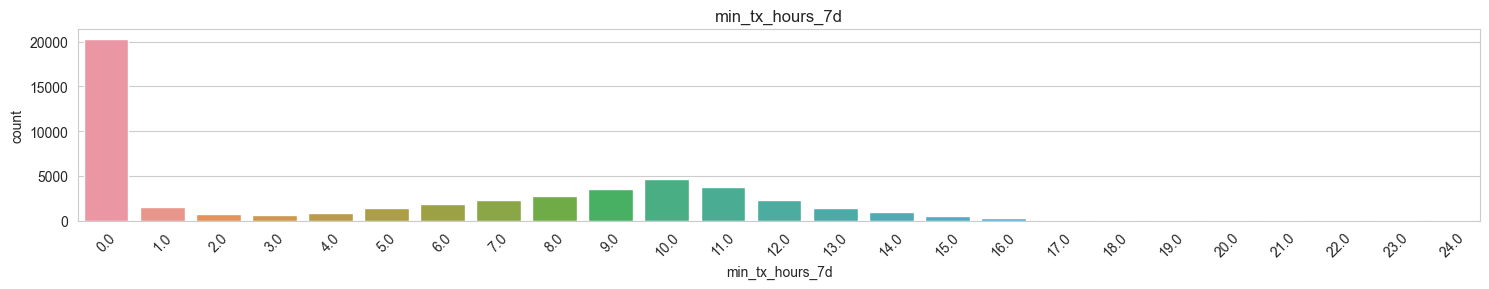

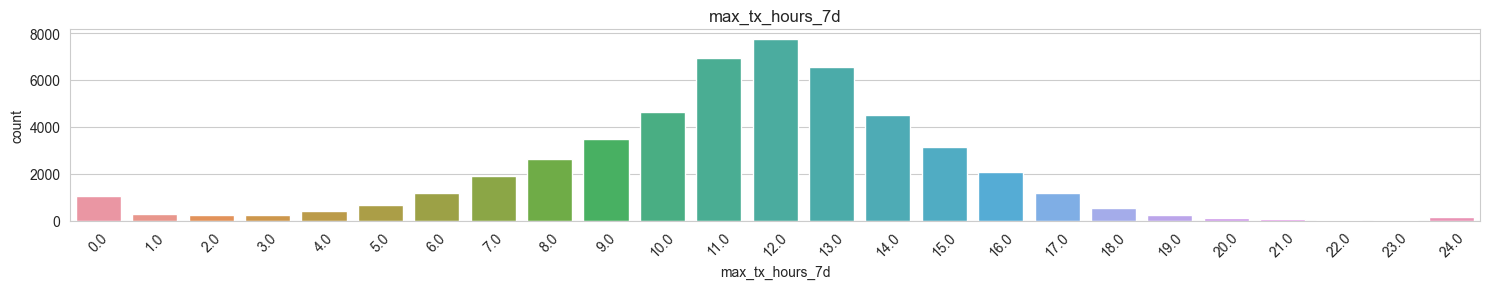

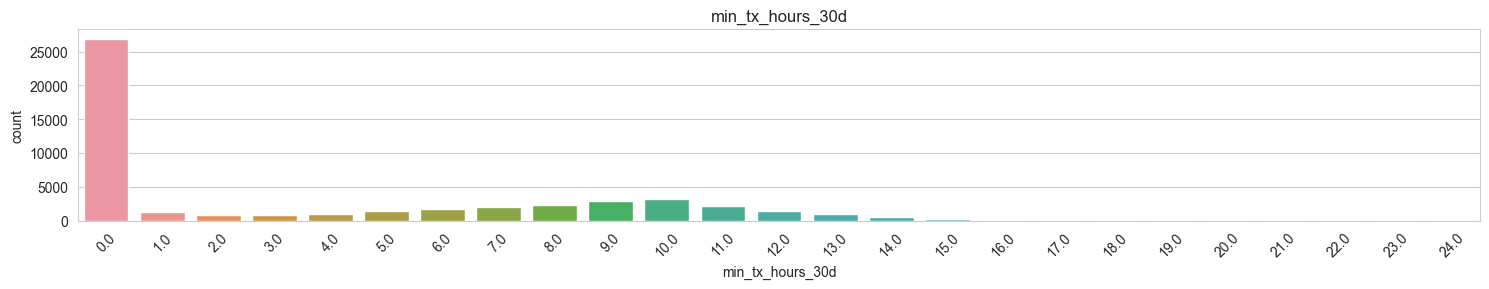

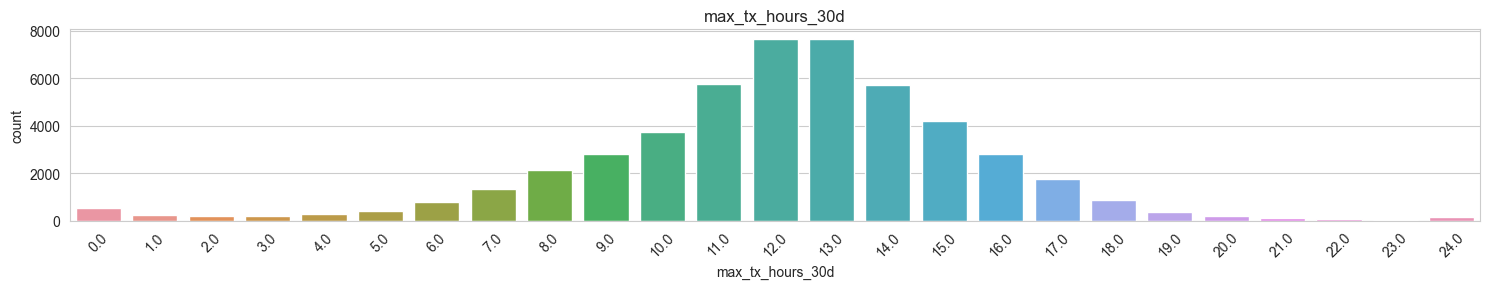

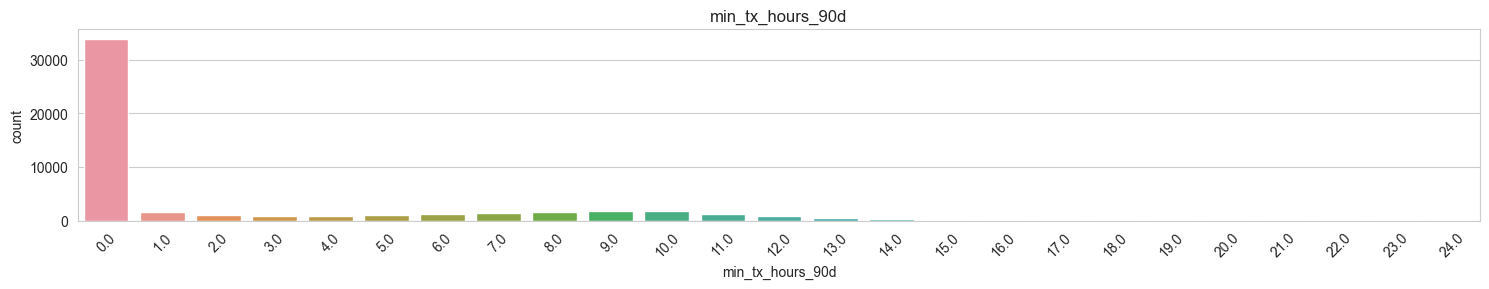

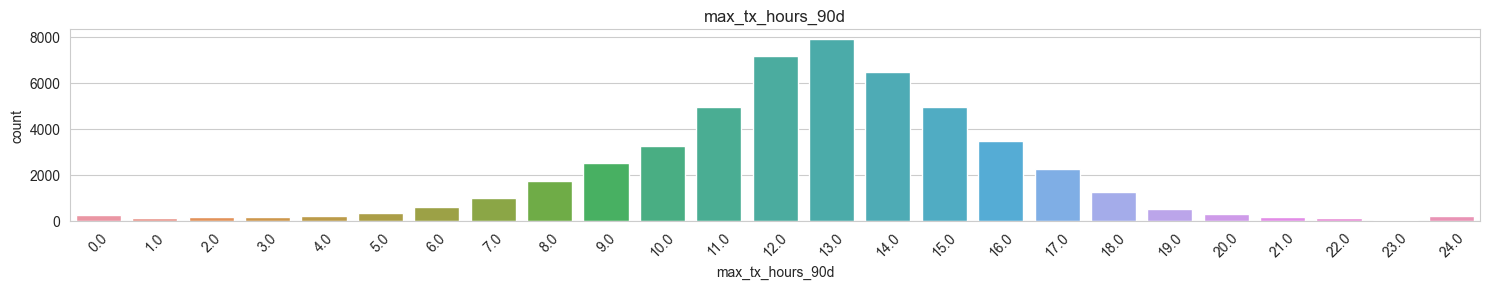

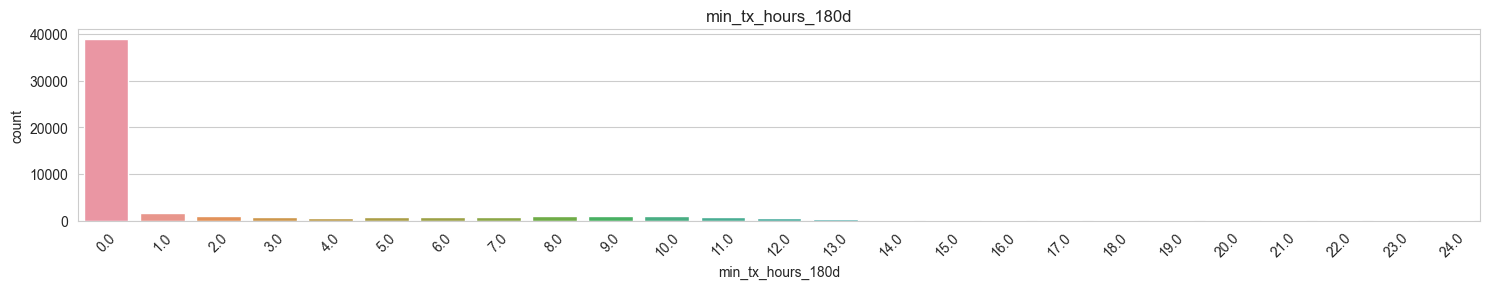

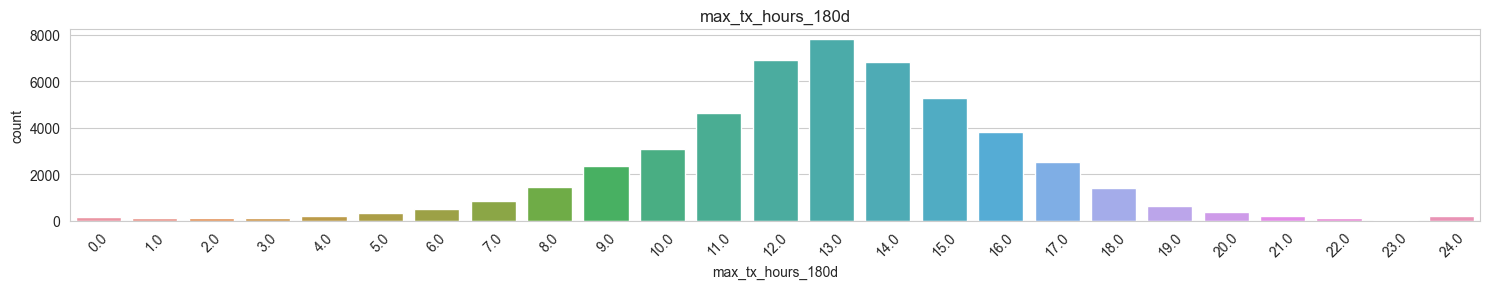

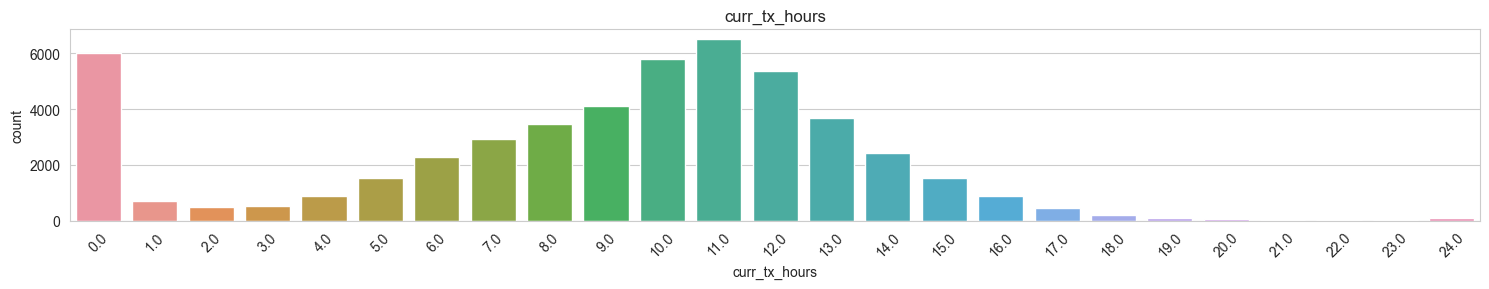

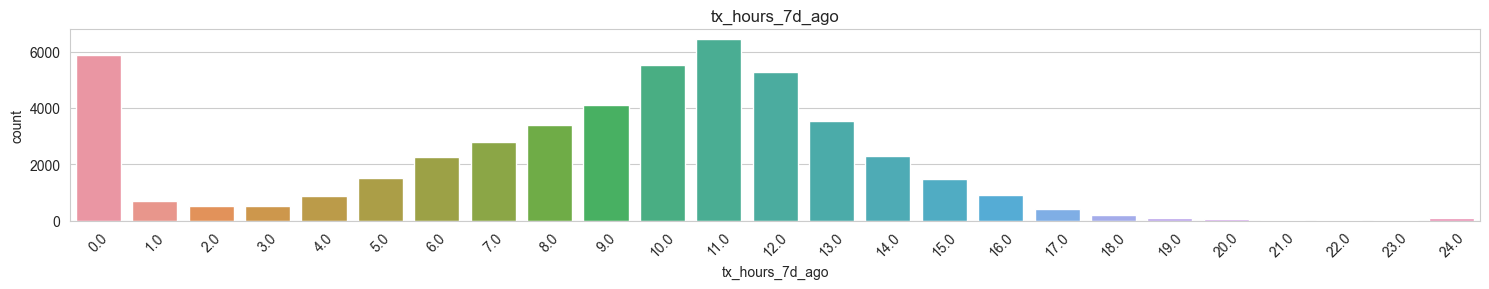

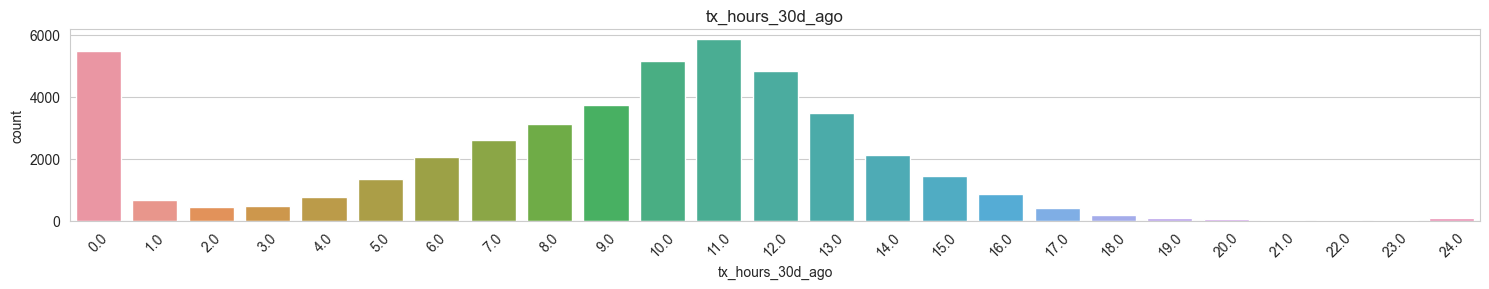

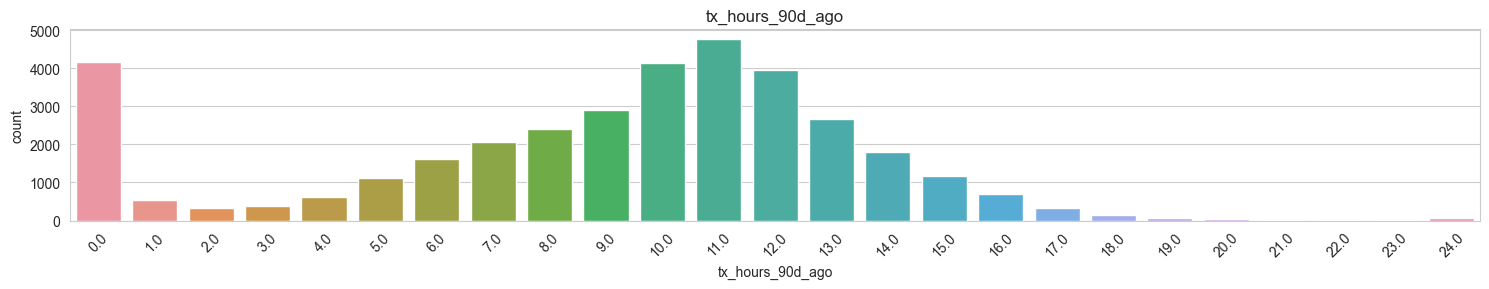

In [15]:
# Low-cardinality distributions (sampled for speed — full df has ~3.5M rows per restaurant-day)
plot_df = df.sample(n=min(50_000, df.height), seed=42) if df.height > 50_000 else df
low_card_cols = (
    df_unique_n
    .filter(pl.col('unique_values') <= 30)
    .get_column('feature_name')
    .to_list()
)

# Cap plots to keep notebook execution practical.
max_plots = 12
low_card_cols = low_card_cols[:max_plots]
plot_df_pd = plot_df.to_pandas()

for col in low_card_cols:
    fig, ax = plt.subplots(figsize=(15, 3))
    sns.countplot(data=plot_df_pd, x=col, ax=ax)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(col)
    plt.tight_layout()


In [16]:
from interpret.glassbox import ExplainableBoostingClassifier

print("Training Explainable Boosting Trees model...")

# Prepare EBM-safe feature matrices
X_train_ebm = X_train.copy()
X_test_ebm = X_test.copy()

# Datetime columns are not directly supported by EBM; convert to int64 epoch ns.
datetime_cols = X_train_ebm.select_dtypes(include=['datetime64[ns]', 'datetimetz']).columns
for c in datetime_cols:
    X_train_ebm[c] = X_train_ebm[c].astype('int64')
    X_test_ebm[c] = X_test_ebm[c].astype('int64')

# Cast string/object-like columns explicitly to string for robust categorical handling.
obj_cols = X_train_ebm.select_dtypes(include=['object']).columns
for c in obj_cols:
    X_train_ebm[c] = X_train_ebm[c].astype(str)
    X_test_ebm[c] = X_test_ebm[c].astype(str)

ebt = ExplainableBoostingClassifier(
    interactions=5,
    outer_bags=2,
    inner_bags=1,
    learning_rate=0.05,
    max_rounds=100,
    random_state=42,
)

# Keep runtime practical on very large training sets.
if len(X_train_ebm) > 100_000:
    print(f"Downsampling EBM training rows from {len(X_train_ebm):,} to 100,000 for runtime.")
    X_ebm_fit, _, y_ebm_fit, _ = train_test_split(
        X_train_ebm,
        y_train,
        stratify=y_train,
        train_size=100_000,
        random_state=42,
    )
else:
    X_ebm_fit, y_ebm_fit = X_train_ebm, y_train

ebt.fit(X_ebm_fit, y_ebm_fit)

# Generate predictions
y_pred_train = ebt.predict_proba(X_train_ebm)[:, 1]
y_pred_test = ebt.predict_proba(X_test_ebm)[:, 1]

# Calculate AUC
train_auc = roc_auc_score(y_train, y_pred_train)
test_auc = roc_auc_score(y_test, y_pred_test)

print(f"\n✓ Model trained successfully")
print(f"✓ Training AUC: {train_auc:.4f}")
print(f"✓ Test AUC: {test_auc:.4f}")
print(f"✓ Overfitting check: {(train_auc - test_auc):.4f} (acceptable if < 0.05)")

Training Explainable Boosting Trees model...


Downsampling EBM training rows from 2,633,009 to 100,000 for runtime.



✓ Model trained successfully
✓ Training AUC: 0.7919
✓ Test AUC: 0.7914
✓ Overfitting check: 0.0005 (acceptable if < 0.05)


DISCRIMINATION METRICS
Train AUC (Area Under Curve): 0.7919
Test AUC (Area Under Curve):  0.7914
Gini Coefficient:             0.5828
K-S Statistic (Test):         0.4166

Rating: ACCEPTABLE - Fair discriminatory power


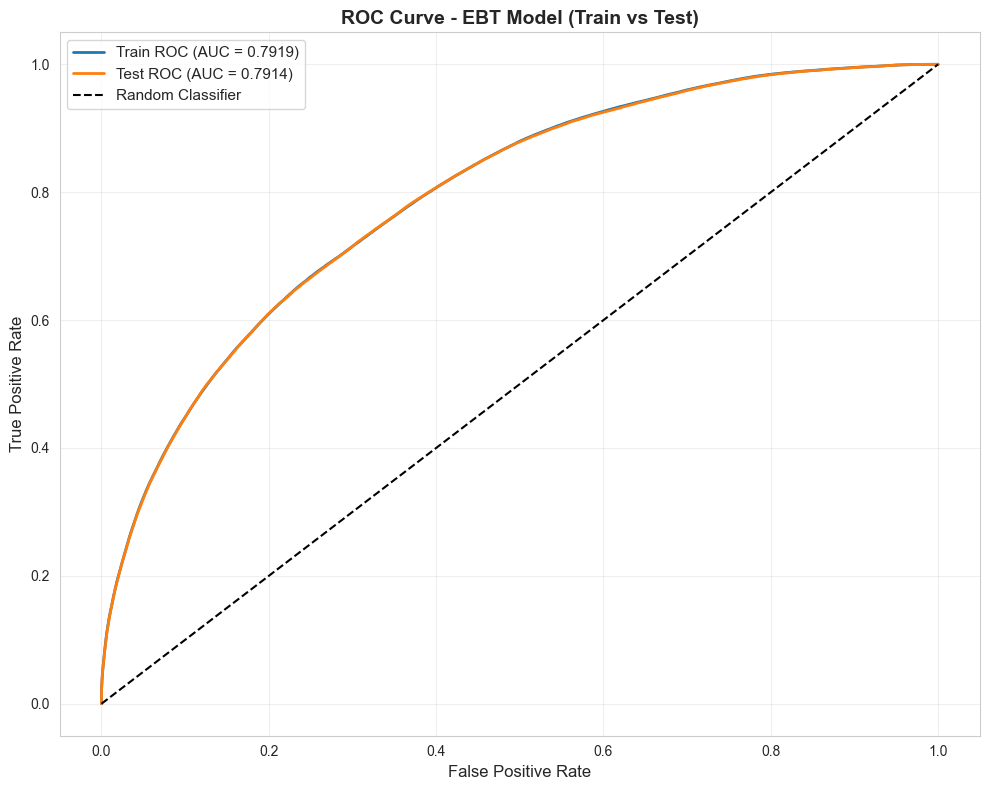

In [17]:
# Calculate discrimination metrics
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_test)
ks_stat = np.max(tpr_test - fpr_test)
gini = 2 * test_auc - 1

print("=" * 70)
print("DISCRIMINATION METRICS")
print("=" * 70)
print(f"Train AUC (Area Under Curve): {train_auc:.4f}")
print(f"Test AUC (Area Under Curve):  {test_auc:.4f}")
print(f"Gini Coefficient:             {gini:.4f}")
print(f"K-S Statistic (Test):         {ks_stat:.4f}")

if test_auc < 0.65:
    rating = "POOR - Model unsuitable for lending"
elif test_auc < 0.70:
    rating = "WEAK - High risk, not recommended"
elif test_auc < 0.75:
    rating = "MARGINAL - Monitor closely"
elif test_auc < 0.80:
    rating = "ACCEPTABLE - Fair discriminatory power"
elif test_auc < 0.85:
    rating = "GOOD - Suitable for credit decisions"
else:
    rating = "EXCELLENT - Strong predictive power"

print(f"\nRating: {rating}")

# Plot train/test ROC curves on same chart
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_auc:.4f})', linewidth=2)
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - EBT Model (Train vs Test)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Top 20 EBM features by importance


,feature,importance
0,avg_proc_vol_180d,0.241300
1,cv_proc_vol_180d,0.230792
2,cv_tx_hours_180d,0.164876
3,avg_tx_hours_180d,0.153777
4,Restaurant_catagory,0.115091
5,Market_segment,0.102699
6,avg_proc_vol_90d,0.095959
7,cv_tx_hours_30d,0.094470
8,cv_proc_vol_90d,0.089394
9,cv_tx_hours_7d,0.073648


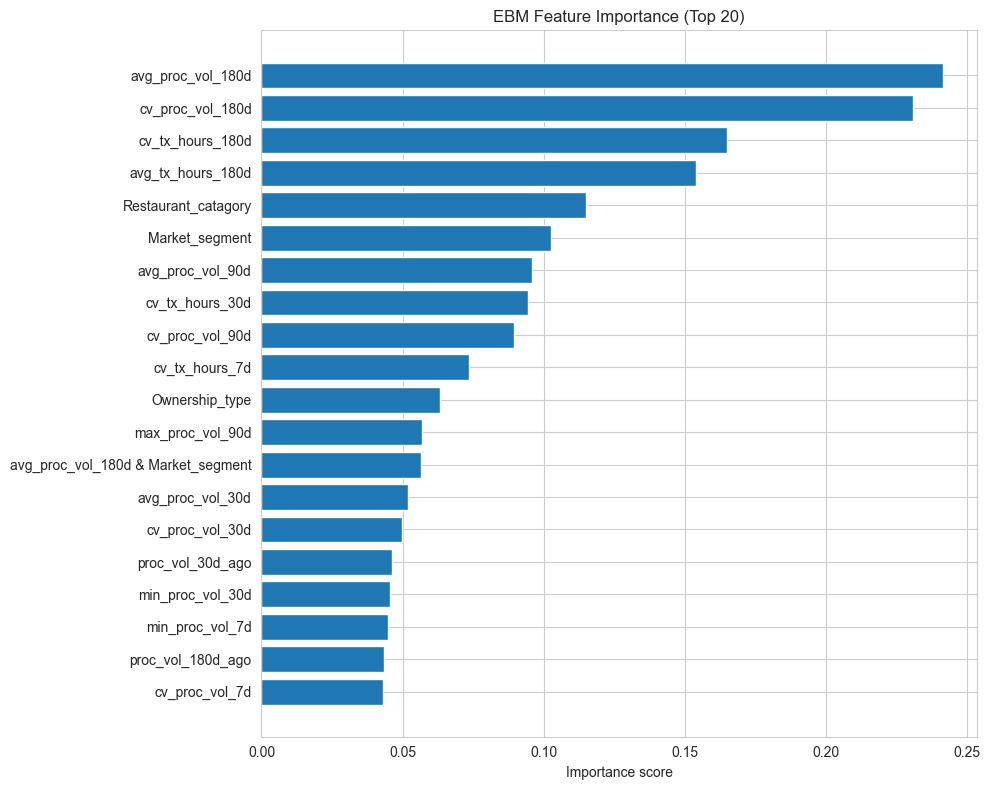

In [18]:
# EBM feature importance (global explanation)
import pandas as pd

global_exp = ebt.explain_global()
exp_data = global_exp.data()

feature_importance = (
    pd.DataFrame({
        'feature': exp_data['names'],
        'importance': exp_data['scores'],
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print('Top 20 EBM features by importance')
display(feature_importance.head(20))

plt.figure(figsize=(10, 8))
plot_df = feature_importance.head(20).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['importance'])
plt.xlabel('Importance score')
plt.title('EBM Feature Importance (Top 20)')
plt.tight_layout()
plt.show()

In [19]:
# All selected model features (after exclusions)
selected_features = list(X_train.columns)
print(f'Total selected features: {len(selected_features)}')
for i, f in enumerate(selected_features, start=1):
    print(f'{i:03d}. {f}')

Total selected features: 56
001. avg_proc_vol_7d
002. min_proc_vol_7d
003. max_proc_vol_7d
004. avg_tx_hours_7d
005. min_tx_hours_7d
006. max_tx_hours_7d
007. cv_proc_vol_7d
008. cv_tx_hours_7d
009. avg_proc_vol_30d
010. min_proc_vol_30d
011. max_proc_vol_30d
012. avg_tx_hours_30d
013. min_tx_hours_30d
014. max_tx_hours_30d
015. cv_proc_vol_30d
016. cv_tx_hours_30d
017. avg_proc_vol_90d
018. min_proc_vol_90d
019. max_proc_vol_90d
020. avg_tx_hours_90d
021. min_tx_hours_90d
022. max_tx_hours_90d
023. cv_proc_vol_90d
024. cv_tx_hours_90d
025. avg_proc_vol_180d
026. min_proc_vol_180d
027. max_proc_vol_180d
028. avg_tx_hours_180d
029. min_tx_hours_180d
030. max_tx_hours_180d
031. cv_proc_vol_180d
032. cv_tx_hours_180d
033. proc_vol_7d_ago
034. tx_hours_7d_ago
035. pct_change_proc_vol_vs_7d_ago
036. pct_change_tx_hours_vs_7d_ago
037. proc_vol_30d_ago
038. tx_hours_30d_ago
039. pct_change_proc_vol_vs_30d_ago
040. pct_change_tx_hours_vs_30d_ago
041. proc_vol_90d_ago
042. tx_hours_90d_ago
043.

In [20]:
# LightGBM + Optuna hyperparameter tuning
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split

print('Training LightGBM model with Optuna tuning...')

# Prepare LightGBM-ready features
X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

# Convert datetime to int64 for LightGBM
for c in X_train_lgbm.select_dtypes(include=['datetime64[ns]', 'datetimetz']).columns:
    X_train_lgbm[c] = X_train_lgbm[c].astype('int64')
    X_test_lgbm[c] = X_test_lgbm[c].astype('int64')

# Cast object columns to category for LightGBM
for c in X_train_lgbm.select_dtypes(include=['object']).columns:
    X_train_lgbm[c] = X_train_lgbm[c].astype('category')
    X_test_lgbm[c] = X_test_lgbm[c].astype('category')

# Runtime-safe tuning subset
if len(X_train_lgbm) > 120_000:
    X_tune, _, y_tune, _ = train_test_split(
        X_train_lgbm,
        y_train,
        stratify=y_train,
        train_size=120_000,
        random_state=42,
    )
else:
    X_tune, y_tune = X_train_lgbm, y_train

X_tr, X_val, y_tr, y_val = train_test_split(
    X_tune,
    y_tune,
    test_size=0.2,
    stratify=y_tune,
    random_state=42,
)

cat_cols = [c for c in X_train_lgbm.columns if str(X_train_lgbm[c].dtype) == 'category']

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1,
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        categorical_feature=cat_cols if cat_cols else 'auto',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    val_pred = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, val_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=1, show_progress_bar=False)

best_params = study.best_params.copy()
best_params.update({'objective': 'binary', 'random_state': 42, 'n_jobs': -1, 'verbosity': -1})

lgbm_model = lgb.LGBMClassifier(**best_params)

# Runtime-safe training subset for final model fit
if len(X_train_lgbm) > 200_000:
    X_fit, _, y_fit, _ = train_test_split(
        X_train_lgbm,
        y_train,
        stratify=y_train,
        train_size=200_000,
        random_state=42,
    )
else:
    X_fit, y_fit = X_train_lgbm, y_train

lgbm_model.fit(
    X_fit,
    y_fit,
    categorical_feature=cat_cols if cat_cols else 'auto',
)

# Predictions
lgbm_pred_train = lgbm_model.predict_proba(X_train_lgbm)[:, 1]
lgbm_pred_test = lgbm_model.predict_proba(X_test_lgbm)[:, 1]

lgbm_train_auc = roc_auc_score(y_train, lgbm_pred_train)
lgbm_test_auc = roc_auc_score(y_test, lgbm_pred_test)

print(f'Best Optuna validation AUC: {study.best_value:.4f}')
print(f'✓ LGBM Training AUC: {lgbm_train_auc:.4f}')
print(f'✓ LGBM Test AUC: {lgbm_test_auc:.4f}')
print(f'✓ LGBM overfitting check: {(lgbm_train_auc - lgbm_test_auc):.4f} (acceptable if < 0.05)')

Training LightGBM model with Optuna tuning...


[I 2026-05-06 09:51:42,047] A new study created in memory with name: no-name-bf30c0f6-ad56-4808-916c-e9958e17b9eb


[I 2026-05-06 09:51:44,936] Trial 0 finished with value: 0.9116123128939073 and parameters: {'n_estimators': 211, 'learning_rate': 0.12396061891126431, 'num_leaves': 67, 'max_depth': 11, 'min_child_samples': 193, 'subsample': 0.8955233042243664, 'colsample_bytree': 0.6251452735149986, 'reg_alpha': 2.5626052528844387, 'reg_lambda': 0.012779416043509795}. Best is trial 0 with value: 0.9116123128939073.


Best Optuna validation AUC: 0.9116
✓ LGBM Training AUC: 0.9440
✓ LGBM Test AUC: 0.9409
✓ LGBM overfitting check: 0.0031 (acceptable if < 0.05)


LGBM DISCRIMINATION METRICS
LGBM Train AUC:               0.9440
LGBM Test AUC:                0.9409
LGBM Gini Coefficient:        0.8819
LGBM K-S Statistic (Test):    0.7264


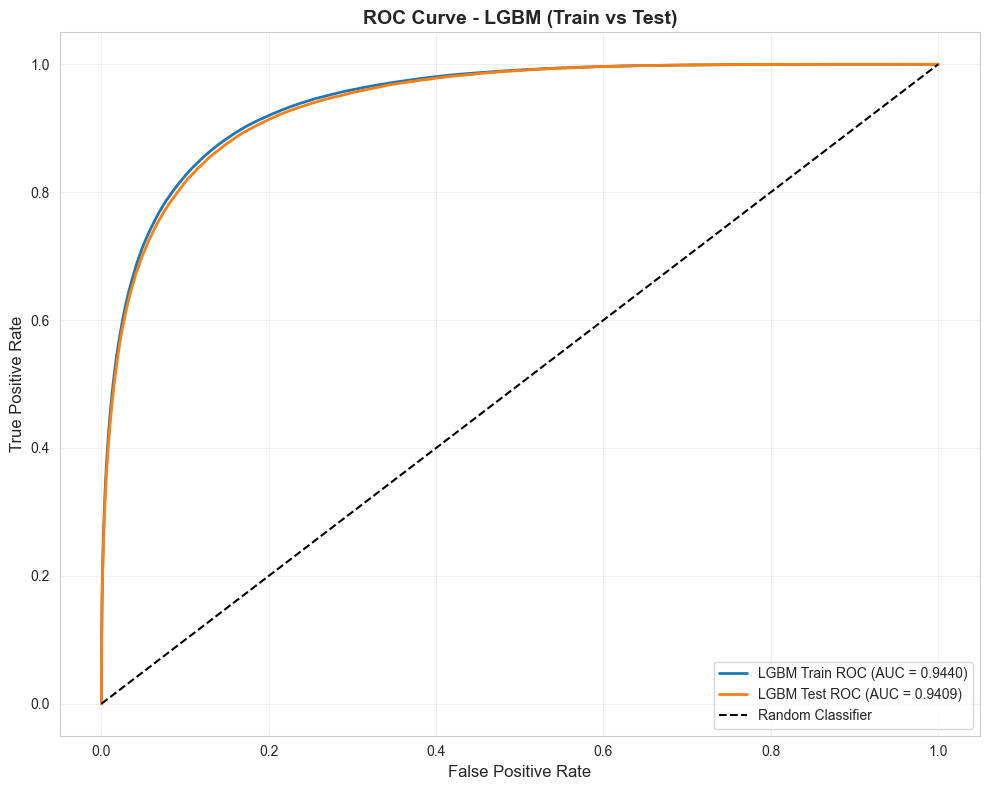

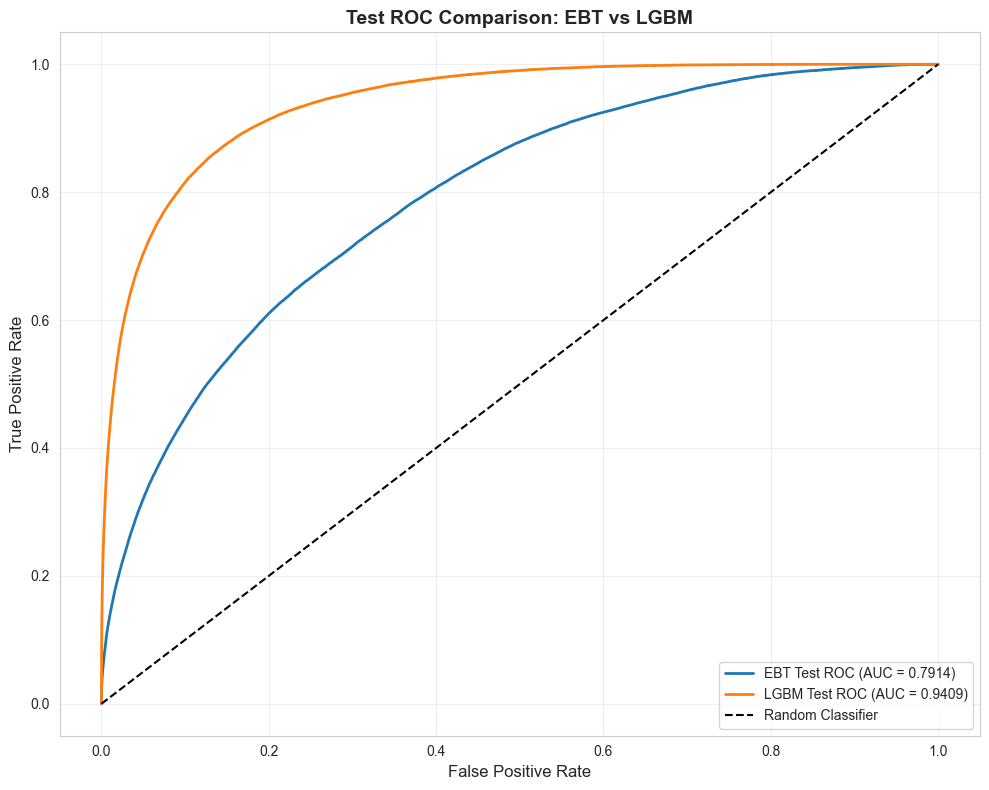

In [21]:
# LGBM discrimination metrics and ROC charts
lgbm_fpr_train, lgbm_tpr_train, _ = roc_curve(y_train, lgbm_pred_train)
lgbm_fpr_test, lgbm_tpr_test, _ = roc_curve(y_test, lgbm_pred_test)
lgbm_ks = np.max(lgbm_tpr_test - lgbm_fpr_test)
lgbm_gini = 2 * lgbm_test_auc - 1

print('=' * 70)
print('LGBM DISCRIMINATION METRICS')
print('=' * 70)
print(f'LGBM Train AUC:               {lgbm_train_auc:.4f}')
print(f'LGBM Test AUC:                {lgbm_test_auc:.4f}')
print(f'LGBM Gini Coefficient:        {lgbm_gini:.4f}')
print(f'LGBM K-S Statistic (Test):    {lgbm_ks:.4f}')

# LGBM train/test ROC
plt.figure(figsize=(10, 8))
plt.plot(lgbm_fpr_train, lgbm_tpr_train, label=f'LGBM Train ROC (AUC = {lgbm_train_auc:.4f})', linewidth=2)
plt.plot(lgbm_fpr_test, lgbm_tpr_test, label=f'LGBM Test ROC (AUC = {lgbm_test_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - LGBM (Train vs Test)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test ROC comparison: EBT vs LGBM
plt.figure(figsize=(10, 8))
plt.plot(fpr_test, tpr_test, label=f'EBT Test ROC (AUC = {test_auc:.4f})', linewidth=2)
plt.plot(lgbm_fpr_test, lgbm_tpr_test, label=f'LGBM Test ROC (AUC = {lgbm_test_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Test ROC Comparison: EBT vs LGBM', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Top 20 LGBM features by importance


,feature,importance
0,max_proc_vol_180d,1038
1,Restaurant_catagory,775
2,avg_tx_hours_180d,719
3,avg_proc_vol_180d,703
4,cv_tx_hours_180d,679
5,cv_proc_vol_180d,566
6,Ownership_type,524
7,max_proc_vol_90d,506
8,max_tx_hours_180d,449
9,avg_tx_hours_90d,430


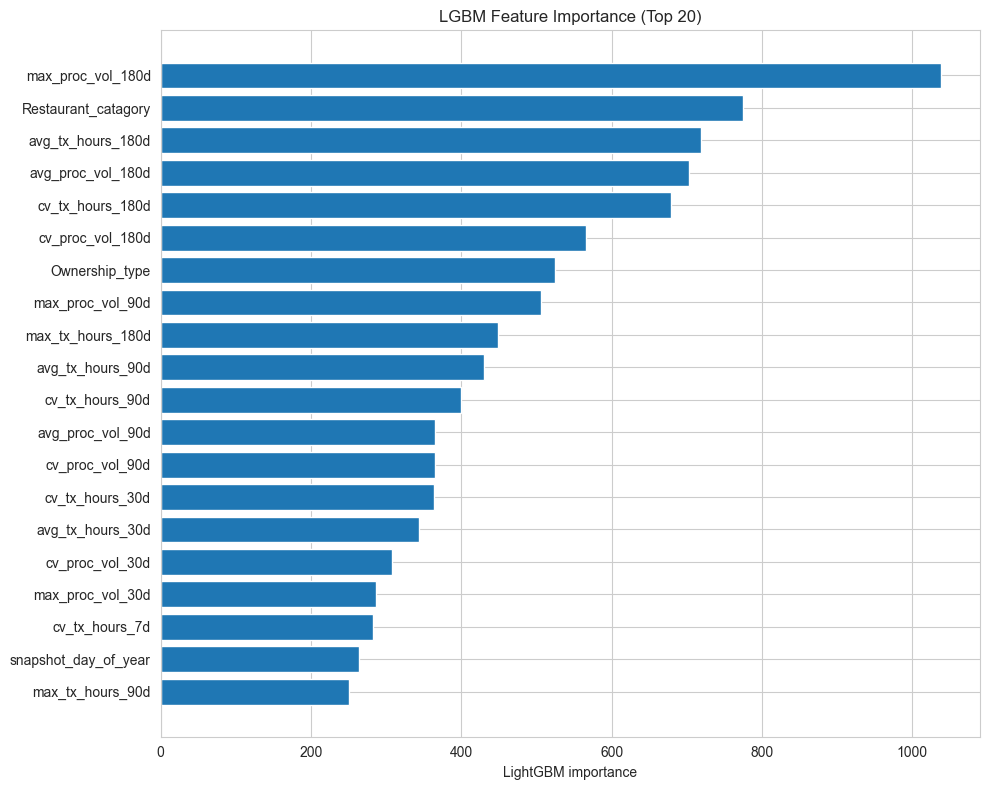

Model performance comparison


,model,train_auc,test_auc,gini,ks_test,overfit_gap
0,EBT,0.7919,0.7914,0.5828,0.4166,0.0005
1,LGBM (Optuna),0.9440,0.9409,0.8819,0.7264,0.0031


In [22]:
# LGBM feature importance and EBT vs LGBM comparison
lgbm_importance = (
    pd.DataFrame({
        'feature': X_train_lgbm.columns,
        'importance': lgbm_model.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print('Top 20 LGBM features by importance')
display(lgbm_importance.head(20))

plt.figure(figsize=(10, 8))
plot_imp = lgbm_importance.head(20).iloc[::-1]
plt.barh(plot_imp['feature'], plot_imp['importance'])
plt.xlabel('LightGBM importance')
plt.title('LGBM Feature Importance (Top 20)')
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame([
    {
        'model': 'EBT',
        'train_auc': train_auc,
        'test_auc': test_auc,
        'gini': 2 * test_auc - 1,
        'ks_test': np.max(tpr_test - fpr_test),
        'overfit_gap': train_auc - test_auc,
    },
    {
        'model': 'LGBM (Optuna)',
        'train_auc': lgbm_train_auc,
        'test_auc': lgbm_test_auc,
        'gini': lgbm_gini,
        'ks_test': lgbm_ks,
        'overfit_gap': lgbm_train_auc - lgbm_test_auc,
    },
])

print('Model performance comparison')
display(comparison_df.round(4))

EBM term effect plots (top features)


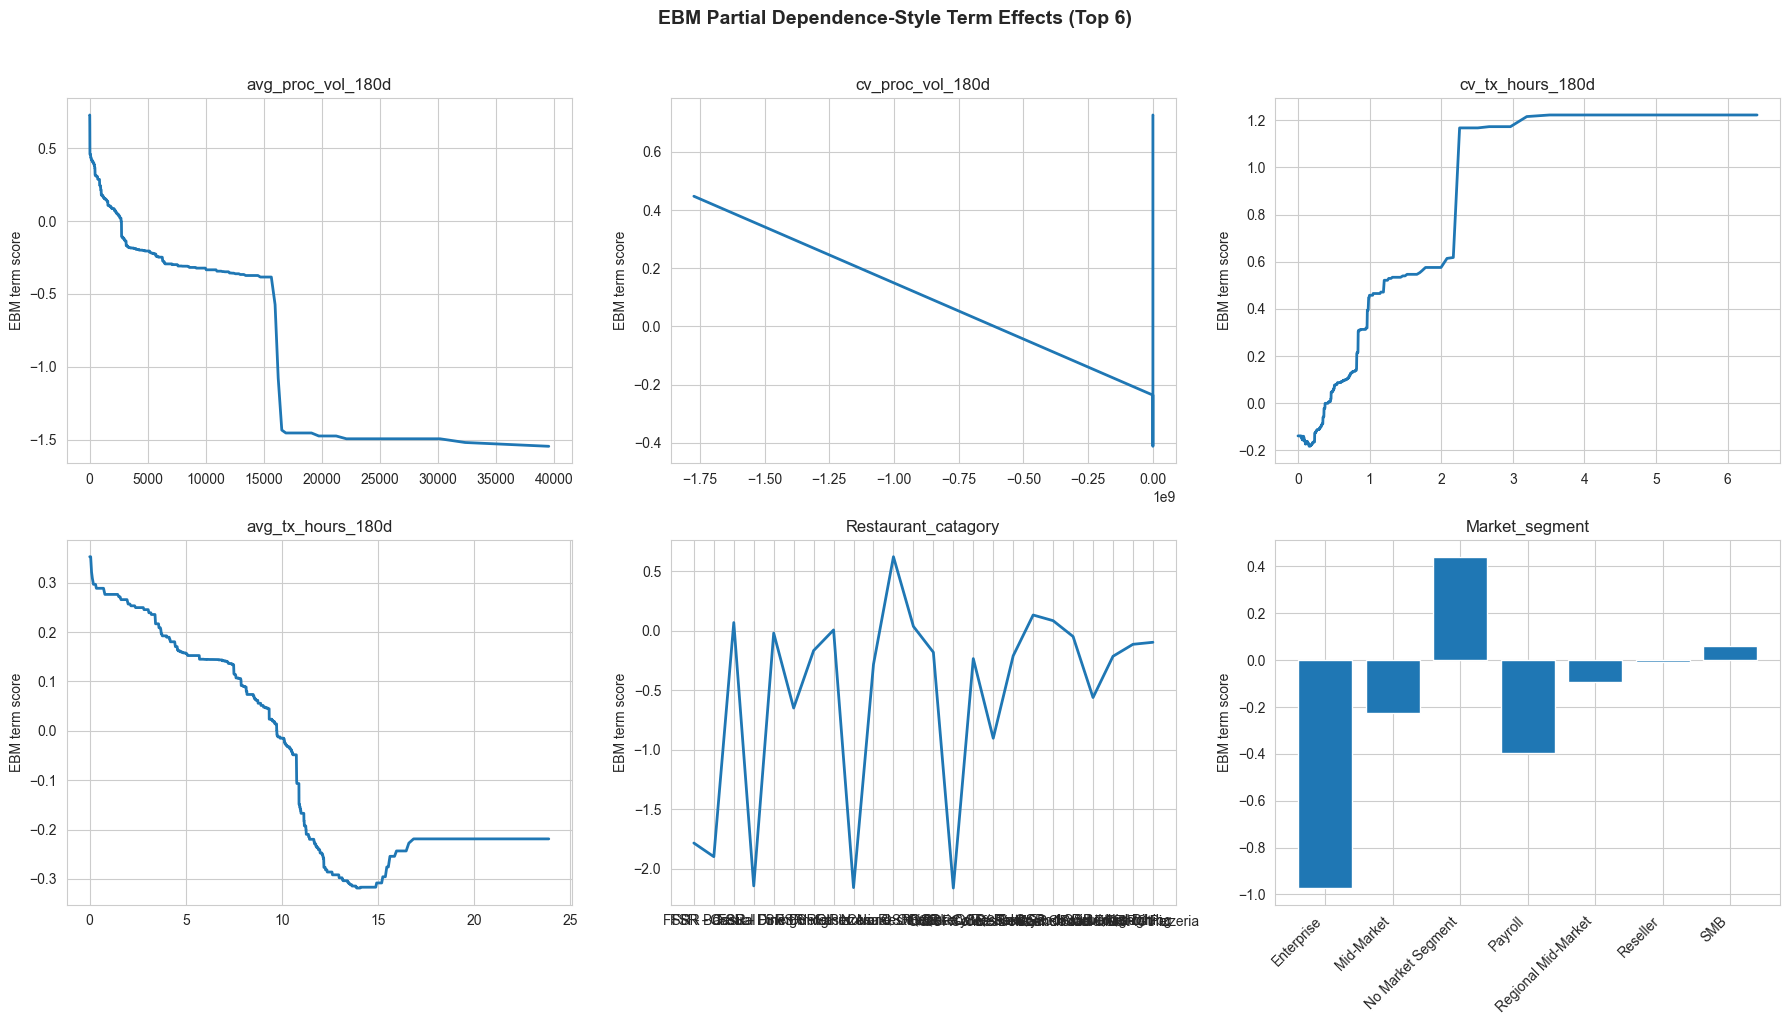

In [23]:
# Partial dependence-style plots for EBM (term effects)
print('EBM term effect plots (top features)')

global_exp_ebm = ebt.explain_global()
ebm_overall = global_exp_ebm.data()

# Use already-computed EBM importance ranking if available
if 'feature_importance' in globals():
    ebm_top_features = feature_importance['feature'].head(6).tolist()
else:
    ebm_top_features = ebm_overall['names'][:6]

ebm_name_to_idx = {name: i for i, name in enumerate(ebm_overall['names'])}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feat in zip(axes, ebm_top_features):
    idx = ebm_name_to_idx.get(feat)
    if idx is None:
        ax.set_visible(False)
        continue

    term = global_exp_ebm.data(idx)
    x_vals = term.get('names', [])
    y_vals = term.get('scores', [])

    # Some EBM terms can return x/y vectors off by one; align safely.
    n = min(len(x_vals), len(y_vals))
    x_plot = x_vals[:n]
    y_plot = y_vals[:n]

    # Numeric terms usually have many x points -> line plot; categoricals -> bar plot.
    if len(x_plot) > 12:
        ax.plot(x_plot, y_plot, linewidth=2)
    else:
        ax.bar(range(len(x_plot)), y_plot)
        ax.set_xticks(range(len(x_plot)))
        ax.set_xticklabels(x_plot, rotation=45, ha='right')

    ax.set_title(feat)
    ax.set_ylabel('EBM term score')

for j in range(len(ebm_top_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('EBM Partial Dependence-Style Term Effects (Top 6)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

LightGBM partial dependence plots (top numeric features)


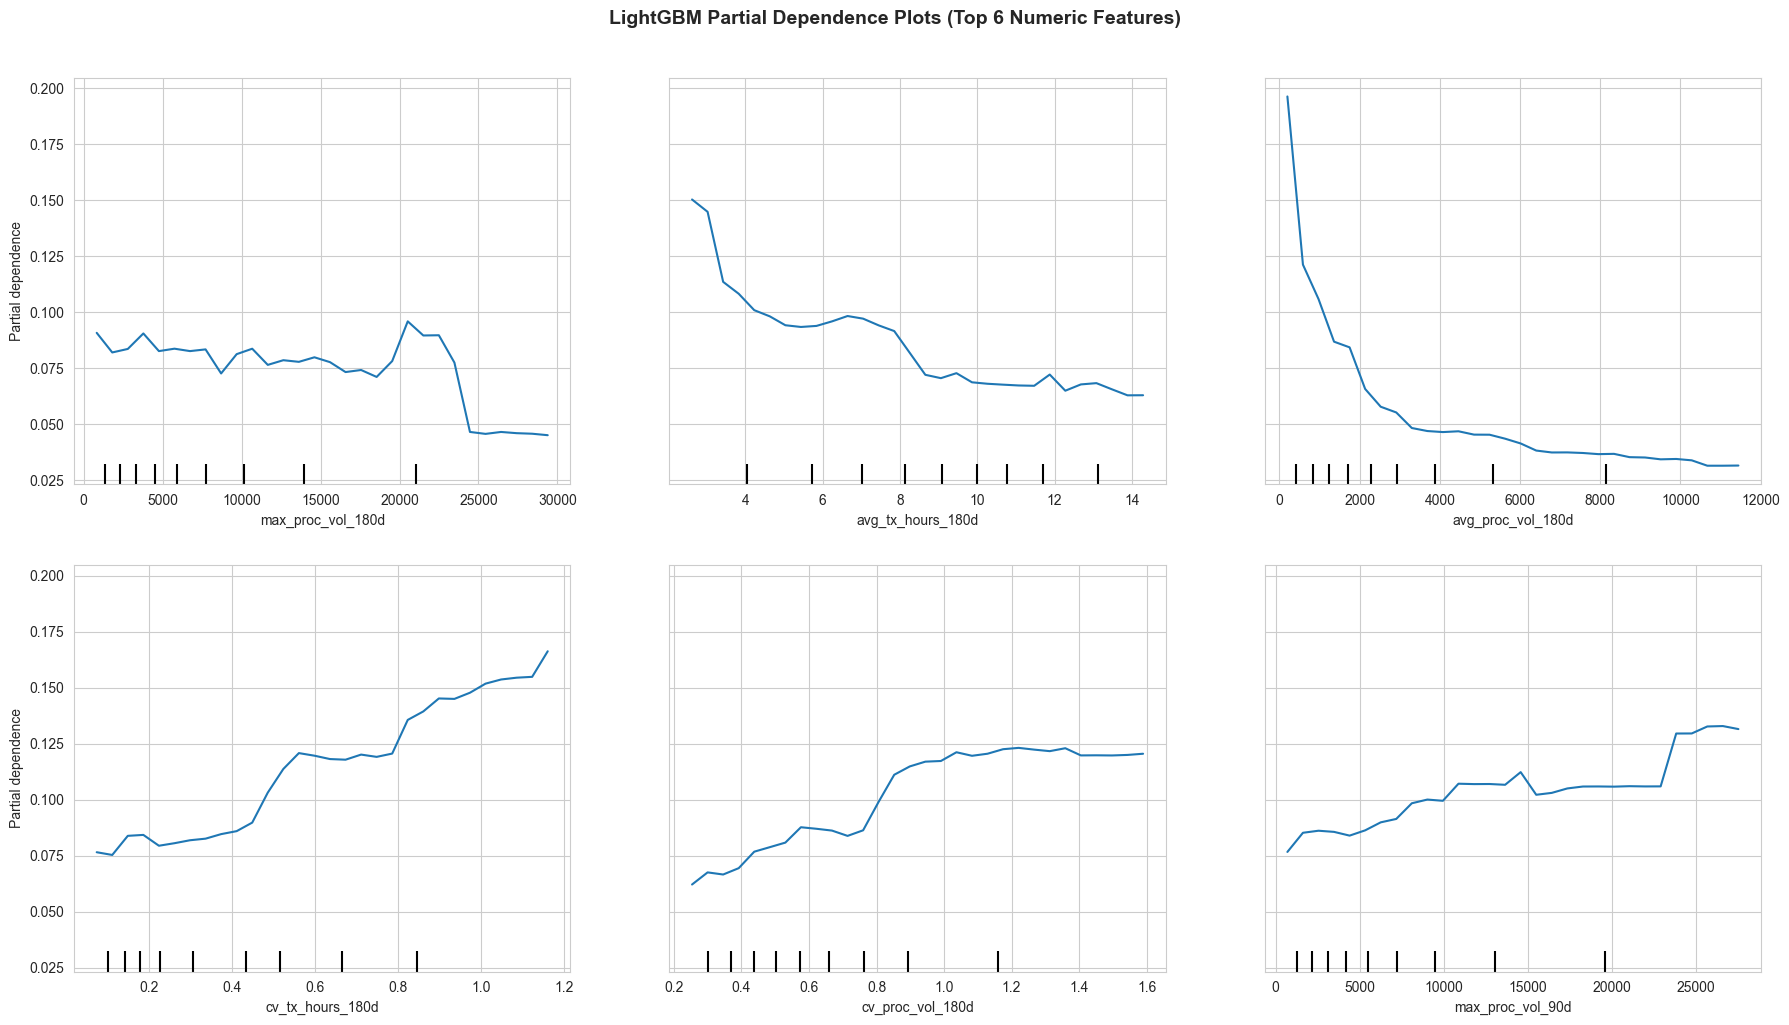

In [24]:
# Partial dependence plots for LightGBM (top numeric features)
from sklearn.inspection import PartialDependenceDisplay

print('LightGBM partial dependence plots (top numeric features)')

numeric_lgbm_features = [
    c for c in lgbm_importance['feature'].tolist()
    if str(X_train_lgbm[c].dtype) not in ('category', 'object')
]

pdp_features = numeric_lgbm_features[:6]

# PDP on a manageable sample for runtime
if len(X_train_lgbm) > 60_000:
    X_pdp = X_train_lgbm.sample(n=60_000, random_state=42)
else:
    X_pdp = X_train_lgbm

fig, ax = plt.subplots(figsize=(18, 10))
PartialDependenceDisplay.from_estimator(
    lgbm_model,
    X_pdp,
    features=pdp_features,
    kind='average',
    grid_resolution=30,
    ax=ax,
)
plt.suptitle('LightGBM Partial Dependence Plots (Top 6 Numeric Features)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Feature elimination and retraining for both EBM and LGBM
print('Running feature elimination for EBM and LGBM...')

# -----------------------------
# 1) EBM feature elimination
# -----------------------------
# Keep features above a weak-importance threshold, but ensure at least top 20 remain.
ebm_importance_df = feature_importance.copy()
ebm_threshold = max(ebm_importance_df['importance'].quantile(0.25), 0)
ebm_keep = ebm_importance_df[ebm_importance_df['importance'] > ebm_threshold]['feature'].tolist()
if len(ebm_keep) < 20:
    ebm_keep = ebm_importance_df.head(20)['feature'].tolist()

# EBM importance can include interaction terms (e.g., 'a & b') that are not raw columns.
ebm_keep = [f for f in ebm_keep if f in X_train_ebm.columns]
if len(ebm_keep) < 20:
    ebm_keep = [f for f in ebm_importance_df['feature'].tolist() if f in X_train_ebm.columns][:20]

ebm_drop = [c for c in X_train_ebm.columns if c not in ebm_keep]

X_train_ebm_sel = X_train_ebm[ebm_keep].copy()
X_test_ebm_sel = X_test_ebm[ebm_keep].copy()

# Runtime-safe subset for EBM selected-model fit
if len(X_train_ebm_sel) > 120_000:
    X_ebm_sel_fit, _, y_ebm_sel_fit, _ = train_test_split(
        X_train_ebm_sel,
        y_train,
        stratify=y_train,
        train_size=120_000,
        random_state=42,
    )
else:
    X_ebm_sel_fit, y_ebm_sel_fit = X_train_ebm_sel, y_train

ebt_sel = ExplainableBoostingClassifier(
    interactions=5,
    outer_bags=2,
    inner_bags=1,
    learning_rate=0.05,
    max_rounds=100,
    random_state=42,
)

ebt_sel.fit(X_ebm_sel_fit, y_ebm_sel_fit)

ebt_sel_pred_train = ebt_sel.predict_proba(X_train_ebm_sel)[:, 1]
ebt_sel_pred_test = ebt_sel.predict_proba(X_test_ebm_sel)[:, 1]

ebt_sel_train_auc = roc_auc_score(y_train, ebt_sel_pred_train)
ebt_sel_test_auc = roc_auc_score(y_test, ebt_sel_pred_test)

# -----------------------------
# 2) LGBM feature elimination
# -----------------------------
lgbm_imp_df = lgbm_importance.copy()
lgbm_threshold = max(lgbm_imp_df['importance'].quantile(0.25), 1)
lgbm_keep = lgbm_imp_df[lgbm_imp_df['importance'] > lgbm_threshold]['feature'].tolist()
if len(lgbm_keep) < 20:
    lgbm_keep = lgbm_imp_df.head(20)['feature'].tolist()

lgbm_drop = [c for c in X_train_lgbm.columns if c not in lgbm_keep]

X_train_lgbm_sel = X_train_lgbm[lgbm_keep].copy()
X_test_lgbm_sel = X_test_lgbm[lgbm_keep].copy()

cat_cols_sel = [c for c in lgbm_keep if str(X_train_lgbm_sel[c].dtype) == 'category']

lgbm_sel = lgb.LGBMClassifier(
    **{
        k: v
        for k, v in best_params.items()
        if k not in ('objective', 'random_state', 'n_jobs', 'verbosity')
    },
    objective='binary',
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

# Runtime-safe subset for LGBM selected-model fit
if len(X_train_lgbm_sel) > 200_000:
    X_lgbm_sel_fit, _, y_lgbm_sel_fit, _ = train_test_split(
        X_train_lgbm_sel,
        y_train,
        stratify=y_train,
        train_size=200_000,
        random_state=42,
    )
else:
    X_lgbm_sel_fit, y_lgbm_sel_fit = X_train_lgbm_sel, y_train

lgbm_sel.fit(
    X_lgbm_sel_fit,
    y_lgbm_sel_fit,
    categorical_feature=cat_cols_sel if cat_cols_sel else 'auto',
)

lgbm_sel_pred_train = lgbm_sel.predict_proba(X_train_lgbm_sel)[:, 1]
lgbm_sel_pred_test = lgbm_sel.predict_proba(X_test_lgbm_sel)[:, 1]

lgbm_sel_train_auc = roc_auc_score(y_train, lgbm_sel_pred_train)
lgbm_sel_test_auc = roc_auc_score(y_test, lgbm_sel_pred_test)

# -----------------------------
# 3) Summaries
# -----------------------------
print('\nEBM feature elimination summary')
print(f'  Original features: {X_train_ebm.shape[1]}')
print(f'  Selected features: {len(ebm_keep)}')
print(f'  Dropped features:  {len(ebm_drop)}')
print(f'  Train AUC (orig -> sel): {train_auc:.4f} -> {ebt_sel_train_auc:.4f}')
print(f'  Test AUC  (orig -> sel): {test_auc:.4f} -> {ebt_sel_test_auc:.4f}')

print('\nLGBM feature elimination summary')
print(f'  Original features: {X_train_lgbm.shape[1]}')
print(f'  Selected features: {len(lgbm_keep)}')
print(f'  Dropped features:  {len(lgbm_drop)}')
print(f'  Train AUC (orig -> sel): {lgbm_train_auc:.4f} -> {lgbm_sel_train_auc:.4f}')
print(f'  Test AUC  (orig -> sel): {lgbm_test_auc:.4f} -> {lgbm_sel_test_auc:.4f}')

fe_compare = pd.DataFrame([
    {'model': 'EBM original', 'n_features': X_train_ebm.shape[1], 'train_auc': train_auc, 'test_auc': test_auc},
    {'model': 'EBM selected', 'n_features': len(ebm_keep), 'train_auc': ebt_sel_train_auc, 'test_auc': ebt_sel_test_auc},
    {'model': 'LGBM original', 'n_features': X_train_lgbm.shape[1], 'train_auc': lgbm_train_auc, 'test_auc': lgbm_test_auc},
    {'model': 'LGBM selected', 'n_features': len(lgbm_keep), 'train_auc': lgbm_sel_train_auc, 'test_auc': lgbm_sel_test_auc},
])

print('\nFeature elimination comparison table')
display(fe_compare.round(4))

print('\nTop dropped EBM features (up to 20):')
print(ebm_drop[:20])
print('\nTop dropped LGBM features (up to 20):')
print(lgbm_drop[:20])

Running feature elimination for EBM and LGBM...



EBM feature elimination summary
  Original features: 56
  Selected features: 41
  Dropped features:  15
  Train AUC (orig -> sel): 0.7919 -> 0.7895
  Test AUC  (orig -> sel): 0.7914 -> 0.7891

LGBM feature elimination summary
  Original features: 56
  Selected features: 42
  Dropped features:  14
  Train AUC (orig -> sel): 0.9440 -> 0.9457
  Test AUC  (orig -> sel): 0.9409 -> 0.9420

Feature elimination comparison table


,model,n_features,train_auc,test_auc
0,EBM original,56,0.7919,0.7914
1,EBM selected,41,0.7895,0.7891
2,LGBM original,56,0.9440,0.9409
3,LGBM selected,42,0.9457,0.9420



Top dropped EBM features (up to 20):
['avg_tx_hours_30d', 'min_tx_hours_30d', 'min_tx_hours_90d', 'max_tx_hours_90d', 'min_tx_hours_180d', 'tx_hours_7d_ago', 'pct_change_proc_vol_vs_7d_ago', 'pct_change_tx_hours_vs_7d_ago', 'tx_hours_30d_ago', 'pct_change_proc_vol_vs_30d_ago', 'pct_change_tx_hours_vs_30d_ago', 'pct_change_tx_hours_vs_90d_ago', 'tx_hours_180d_ago', 'pct_change_tx_hours_vs_180d_ago', 'snapshot_day_of_week']

Top dropped LGBM features (up to 20):
['min_tx_hours_7d', 'min_tx_hours_30d', 'min_tx_hours_90d', 'min_tx_hours_180d', 'tx_hours_7d_ago', 'pct_change_tx_hours_vs_7d_ago', 'tx_hours_30d_ago', 'pct_change_tx_hours_vs_30d_ago', 'pct_change_tx_hours_vs_90d_ago', 'pct_change_tx_hours_vs_180d_ago', 'snapshot_day_of_week', 'snapshot_month', 'snapshot_quarter', 'Restaurant_cat']


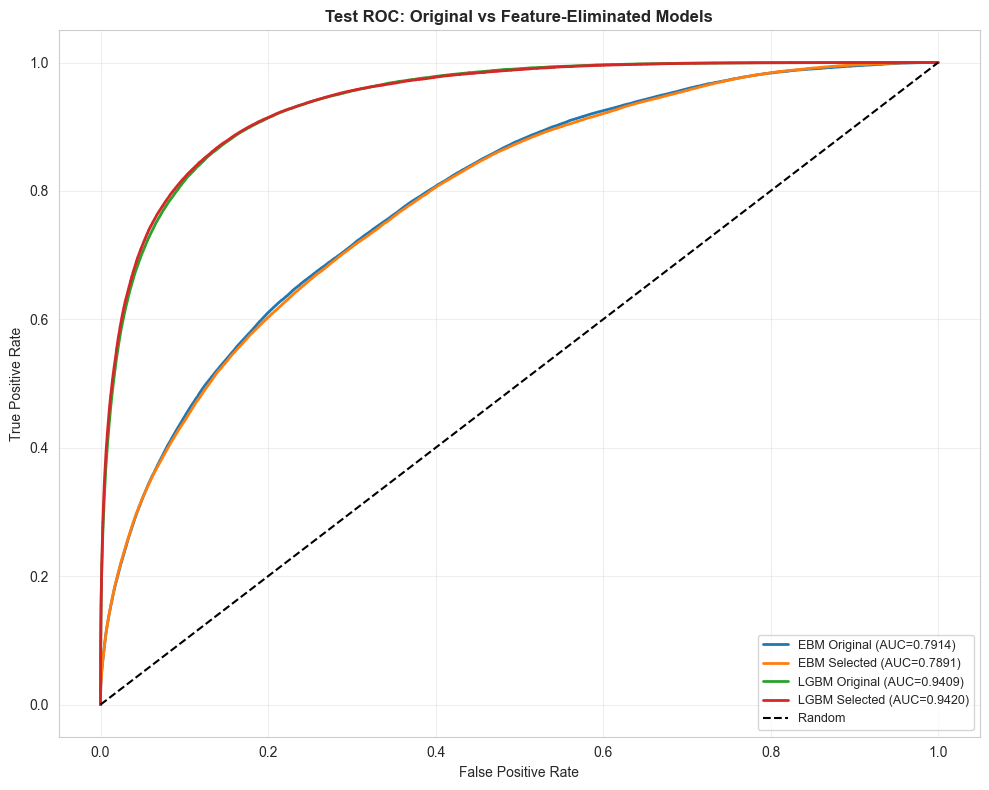

In [26]:
# ROC comparison: original vs feature-eliminated models
ebt_sel_fpr_test, ebt_sel_tpr_test, _ = roc_curve(y_test, ebt_sel_pred_test)
lgbm_sel_fpr_test, lgbm_sel_tpr_test, _ = roc_curve(y_test, lgbm_sel_pred_test)

plt.figure(figsize=(10, 8))
plt.plot(fpr_test, tpr_test, label=f'EBM Original (AUC={test_auc:.4f})', linewidth=2)
plt.plot(ebt_sel_fpr_test, ebt_sel_tpr_test, label=f'EBM Selected (AUC={ebt_sel_test_auc:.4f})', linewidth=2)
plt.plot(lgbm_fpr_test, lgbm_tpr_test, label=f'LGBM Original (AUC={lgbm_test_auc:.4f})', linewidth=2)
plt.plot(lgbm_sel_fpr_test, lgbm_sel_tpr_test, label=f'LGBM Selected (AUC={lgbm_sel_test_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC: Original vs Feature-Eliminated Models', fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()